Critical angle     : 48.59°
Critical distance  : 68.03 km
Vertical TWT (x=0) : 10.0000 s


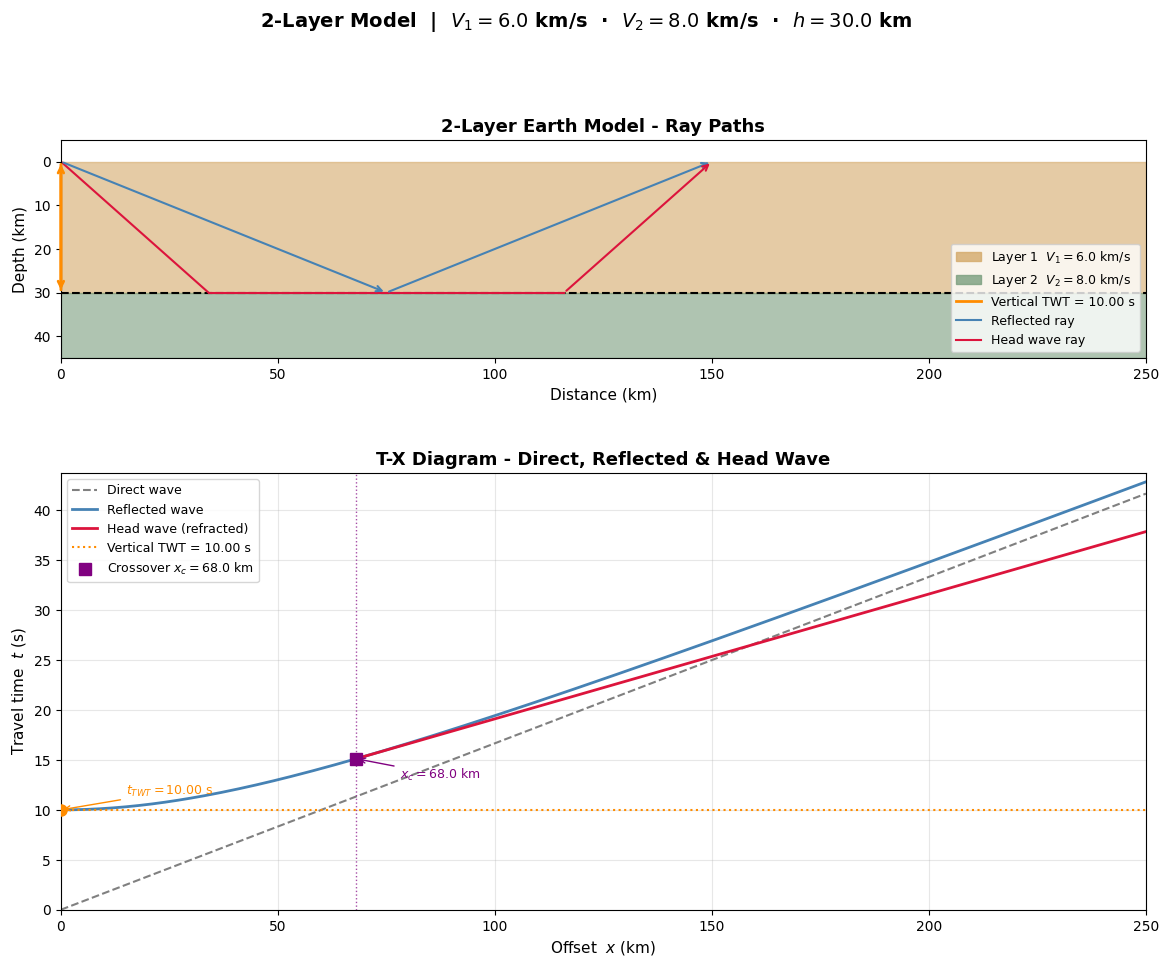

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

v1 = 6.0
v2 = 8.0
h  = 30.0 
x_max = 250.0 

ic = np.arcsin(v1 / v2)          #(in radians)
x_cross = 2 * h * np.tan(ic)

x = np.arange(0, x_max + 1, 1.0)   # km


# 1. Direct wave
t_direct = x / v1

# 2. Reflected wave
t_reflect = (2 / v1) * np.sqrt(h**2 + (x / 2)**2)

# 3. Head wave
t_head = x / v2 + (2 * h * np.cos(ic)) / v1
t_head[x < x_cross] = np.nan          

t_twt = 2 * h / v1
print(f"Critical angle     : {np.degrees(ic):.2f}°")
print(f"Critical distance  : {x_cross:.2f} km")
print(f"Vertical TWT (x=0) : {t_twt:.4f} s")

fig = plt.figure(figsize=(14, 10))
gs  = fig.add_gridspec(2, 1, height_ratios=[1, 2], hspace=0.35)

ax_model = fig.add_subplot(gs[0])

ax_model.fill_between([0, x_max], [0, 0], [-h, -h],
                       color='#d4a96a', alpha=0.6, label=f'Layer 1  $V_1={v1}$ km/s')
ax_model.fill_between([0, x_max], [-h, -h], [-h - 15, -h - 15],
                       color='#7a9e7e', alpha=0.6, label=f'Layer 2  $V_2={v2}$ km/s')

# interface line
ax_model.axhline(-h, color='k', lw=1.5, ls='--')

x_recv = 150.0   # example receiver offset

# reflected ray
ax_model.annotate('', xy=(x_recv, 0), xytext=(x_recv / 2, -h),
                  arrowprops=dict(arrowstyle='->', color='steelblue', lw=1.5))
ax_model.annotate('', xy=(x_recv / 2, -h), xytext=(0, 0),
                  arrowprops=dict(arrowstyle='->', color='steelblue', lw=1.5))

# head wave ray
x_c1 = h * np.tan(ic)
x_c2 = x_recv - h * np.tan(ic)
ax_model.plot([0, x_c1], [0, -h], color='crimson', lw=1.5)
ax_model.plot([x_c1, x_c2], [-h, -h], color='crimson', lw=1.5, ls='-')
ax_model.annotate('', xy=(x_recv, 0), xytext=(x_c2, -h),
                  arrowprops=dict(arrowstyle='->', color='crimson', lw=1.5))

# TWT ray
ax_model.annotate('', xy=(0, -h), xytext=(0, 0),
                  arrowprops=dict(arrowstyle='->', color='darkorange', lw=2))
ax_model.annotate('', xy=(0, 0), xytext=(0, -h),
                  arrowprops=dict(arrowstyle='->', color='darkorange', lw=2))

ax_model.set_xlim(0, x_max)
ax_model.set_ylim(-h - 15, 5)
ax_model.set_xlabel('Distance (km)', fontsize=11)
ax_model.set_ylabel('Depth (km)', fontsize=11)
ax_model.set_title('2-Layer Earth Model - Ray Paths', fontsize=13, fontweight='bold')
ax_model.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{abs(v):.0f}'))

legend_patches = [
    mpatches.Patch(color='#d4a96a', alpha=0.8, label=f'Layer 1  $V_1 = {v1}$ km/s'),
    mpatches.Patch(color='#7a9e7e', alpha=0.8, label=f'Layer 2  $V_2 = {v2}$ km/s'),
    plt.Line2D([0], [0], color='darkorange', lw=2,  label=f'Vertical TWT = {t_twt:.2f} s'),
    plt.Line2D([0], [0], color='steelblue', lw=1.5, label='Reflected ray'),
    plt.Line2D([0], [0], color='crimson',   lw=1.5, label='Head wave ray'),
]
ax_model.legend(handles=legend_patches, loc='lower right', fontsize=9)

ax_tx = fig.add_subplot(gs[1])

ax_tx.plot(x, t_direct,  color='gray',      lw=1.5, ls='--', label='Direct wave')
ax_tx.plot(x, t_reflect, color='steelblue', lw=2,            label='Reflected wave')
ax_tx.plot(x, t_head,    color='crimson',   lw=2,            label='Head wave (refracted)')

# vertical TWT marker at x=0
ax_tx.axhline(t_twt, color='darkorange', lw=1.5, ls=':',
              label=f'Vertical TWT = {t_twt:.2f} s')
ax_tx.plot(0, t_twt, 'o', color='darkorange', ms=8, zorder=5)

# crossover point
t_cross = x_cross / v2 + (2 * h * np.cos(ic)) / v1
ax_tx.axvline(x_cross, color='purple', lw=1, ls=':', alpha=0.7)
ax_tx.plot(x_cross, t_cross, 's', color='purple', ms=8, zorder=5,
           label=f'Crossover $x_c={x_cross:.1f}$ km')

# annotations
ax_tx.annotate(f'$t_{{TWT}}={t_twt:.2f}$ s',
               xy=(0, t_twt), xytext=(15, t_twt + 1.5),
               fontsize=9, color='darkorange',
               arrowprops=dict(arrowstyle='->', color='darkorange', lw=1))

ax_tx.annotate(f'$x_c={x_cross:.1f}$ km',
               xy=(x_cross, t_cross), xytext=(x_cross + 10, t_cross - 2),
               fontsize=9, color='purple',
               arrowprops=dict(arrowstyle='->', color='purple', lw=1))

ax_tx.set_xlim(0, x_max)
ax_tx.set_ylim(0, x_max / v1 * 1.05)
ax_tx.set_xlabel('Offset  $x$ (km)', fontsize=11)
ax_tx.set_ylabel('Travel time  $t$ (s)', fontsize=11)
ax_tx.set_title('T-X Diagram - Direct, Reflected & Head Wave', fontsize=13, fontweight='bold')
ax_tx.legend(fontsize=9, loc='upper left')
ax_tx.grid(True, alpha=0.3)

plt.suptitle(
    f'2-Layer Model  |  $V_1={v1}$ km/s  ·  $V_2={v2}$ km/s  ·  $h={h}$ km',
    fontsize=14, fontweight='bold', y=1.01
)

plt.savefig('earth_model_es1.png', dpi=150, bbox_inches='tight')
plt.show()


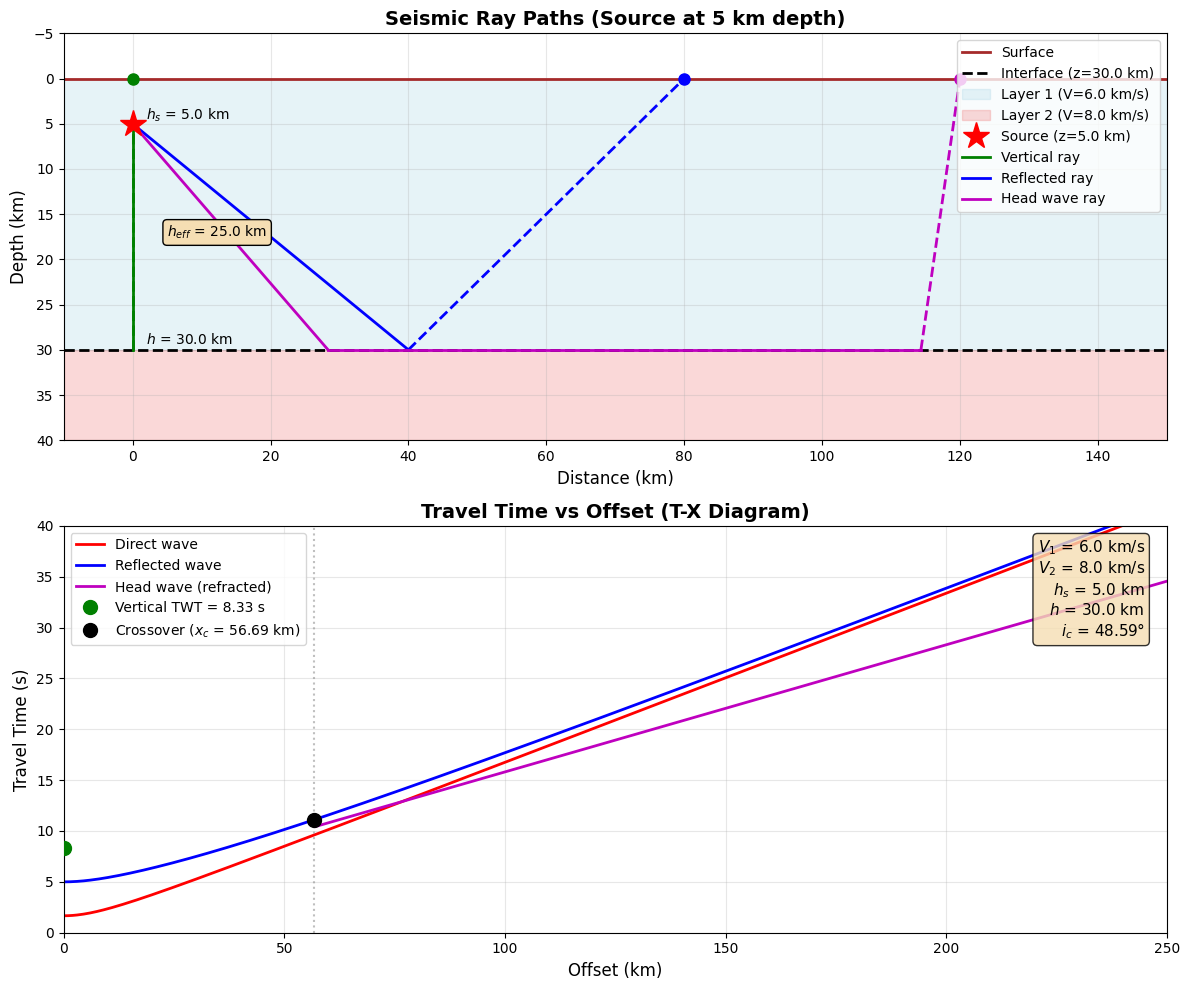

Critical angle: 48.59°
Crossover distance: 56.69 km
Vertical TWT: 8.33 s
Source depth: 5.0 km
Effective depth: 25.0 km


In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Physical parameters
V1 = 6.0  # km/s, velocity of layer 1
V2 = 8.0  # km/s, velocity of layer 2
h = 30.0  # km, depth to interface
h_s = 5.0  # km, source depth
h_eff = h - h_s  # effective depth from source to interface
x_max = 250.0  # km, maximum offset

# Critical angle and crossover distance
i_c = np.arcsin(V1 / V2)  # critical angle in radians
x_c = 2 * h_eff * np.tan(i_c)  # crossover distance

# Offset array
x = np.linspace(0, x_max, 500)


t_direct = np.sqrt((x)**2 + (2*h_s)**2) / V1


t_reflect = np.sqrt((x/2)**2 + h_eff**2) / V1 + np.sqrt((x/2)**2 + h_s**2) / V1


t_head = np.where(
    x >= x_c,
    x / V2 + h_eff * np.cos(i_c) / V1 + h_s * np.cos(i_c) / V1,
    np.nan
)

t_TWT = 2 * h_eff / V1

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

ax1.set_xlim(-10, 150)
ax1.set_ylim(40, -5)
ax1.set_xlabel('Distance (km)', fontsize=12)
ax1.set_ylabel('Depth (km)', fontsize=12)
ax1.set_title('Seismic Ray Paths (Source at 5 km depth)', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)

# Draw layers
ax1.axhline(y=0, color='brown', linewidth=2, label='Surface')
ax1.axhline(y=h, color='black', linewidth=2, linestyle='--', label=f'Interface (z={h} km)')
ax1.fill_between([-10, 150], 0, h, color='lightblue', alpha=0.3, label=f'Layer 1 (V={V1} km/s)')
ax1.fill_between([-10, 150], h, 40, color='lightcoral', alpha=0.3, label=f'Layer 2 (V={V2} km/s)')

ax1.plot(0, h_s, 'r*', markersize=20, label=f'Source (z={h_s} km)', zorder=5)

# Ray path 1: Vertical TWT (down and back up to surface above source)
ax1.plot([0, 0], [h_s, h], 'g-', linewidth=2, label='Vertical ray')
ax1.plot([0, 0], [h, h_s], 'g--', linewidth=2)
ax1.plot(0, 0, 'go', markersize=8)

x_refl = 80
x_refl_point = x_refl / 2
z_refl_point = h
ax1.plot([0, x_refl_point], [h_s, z_refl_point], 'b-', linewidth=2, label='Reflected ray')
ax1.plot([x_refl_point, x_refl], [z_refl_point, 0], 'b--', linewidth=2)
ax1.plot(x_refl, 0, 'bo', markersize=8)

x_head = 120
x_down = h_eff * np.tan(i_c)
x_up = h_s * np.tan(i_c)
x_along = x_head - x_down - x_up
ax1.plot([0, x_down], [h_s, h], 'm-', linewidth=2, label='Head wave ray')
ax1.plot([x_down, x_down + x_along], [h, h], 'm-', linewidth=2)
ax1.plot([x_down + x_along, x_head], [h, 0], 'm--', linewidth=2)
ax1.plot(x_head, 0, 'mo', markersize=8)

ax1.text(2, h_s, f'$h_s$ = {h_s} km', fontsize=10, va='bottom')
ax1.text(2, h-2, f'$h$ = {h} km', fontsize=10, va='top')
ax1.text(5, (h_s + h)/2, f'$h_{{eff}}$ = {h_eff} km', fontsize=10, bbox=dict(boxstyle='round', facecolor='wheat'))

ax1.legend(loc='upper right', fontsize=10)

ax2.plot(x, t_direct, 'r-', linewidth=2, label='Direct wave')
ax2.plot(x, t_reflect, 'b-', linewidth=2, label='Reflected wave')
ax2.plot(x, t_head, 'm-', linewidth=2, label='Head wave (refracted)')

ax2.plot(0, t_TWT, 'go', markersize=10, label=f'Vertical TWT = {t_TWT:.2f} s', zorder=5)

t_cross = np.sqrt((x_c/2)**2 + h_eff**2) / V1 + np.sqrt((x_c/2)**2 + h_s**2) / V1
ax2.plot(x_c, t_cross, 'ko', markersize=10, label=f'Crossover ($x_c$ = {x_c:.2f} km)', zorder=5)
ax2.axvline(x=x_c, color='gray', linestyle=':', alpha=0.5)

ax2.set_xlabel('Offset (km)', fontsize=12)
ax2.set_ylabel('Travel Time (s)', fontsize=12)
ax2.set_title('Travel Time vs Offset (T-X Diagram)', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend(loc='upper left', fontsize=10)
ax2.set_xlim(0, x_max)
ax2.set_ylim(0, 40)

textstr = f'$V_1$ = {V1} km/s\n$V_2$ = {V2} km/s\n$h_s$ = {h_s} km\n$h$ = {h} km\n$i_c$ = {np.degrees(i_c):.2f}°'
ax2.text(0.98, 0.97, textstr, transform=ax2.transAxes, fontsize=11,
         verticalalignment='top', horizontalalignment='right',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.savefig('earth_model_source_depth.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Critical angle: {np.degrees(i_c):.2f}°")
print(f"Crossover distance: {x_c:.2f} km")
print(f"Vertical TWT: {t_TWT:.2f} s")
print(f"Source depth: {h_s} km")
print(f"Effective depth: {h_eff} km")


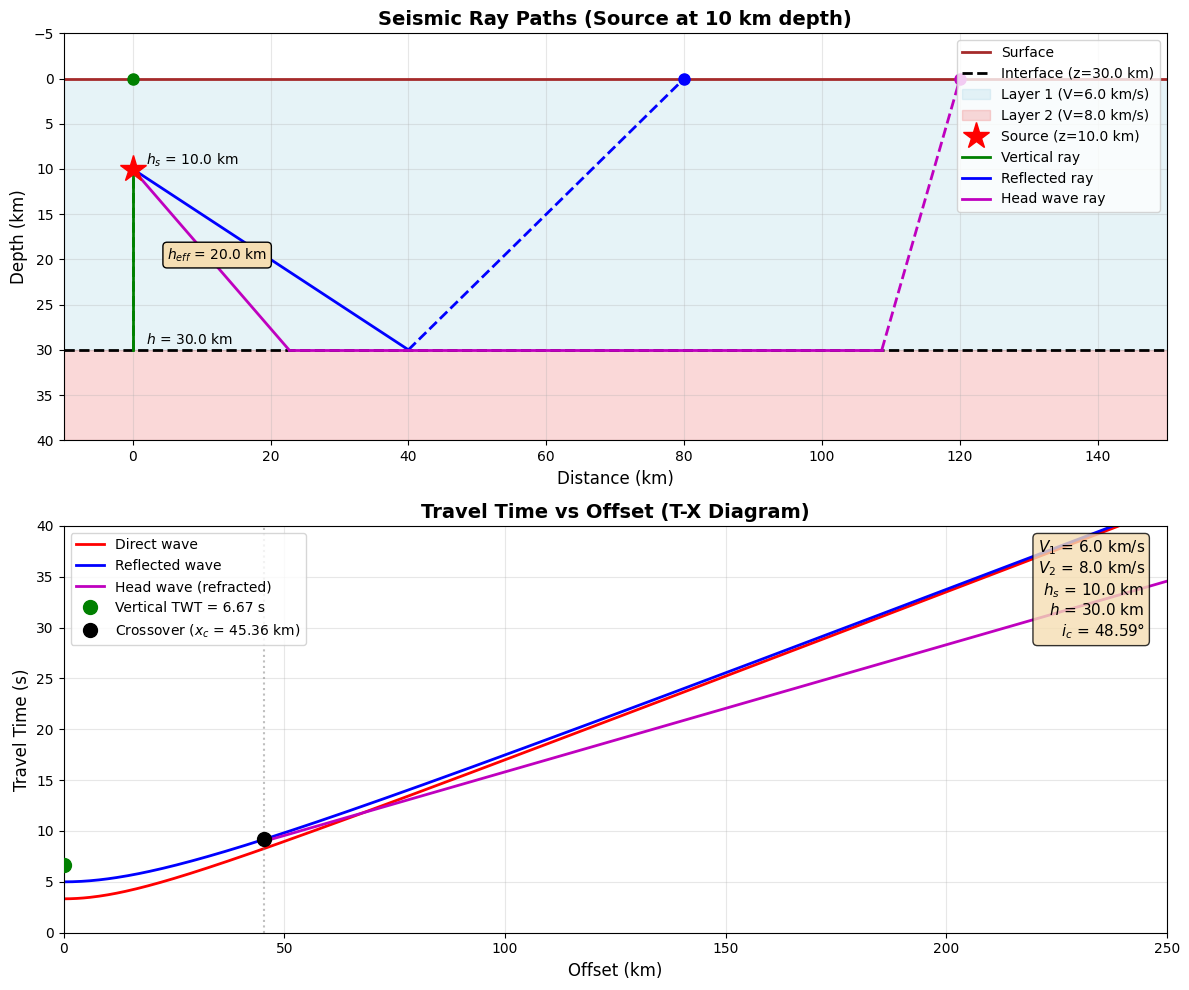

Critical angle: 48.59°
Crossover distance: 45.36 km
Vertical TWT: 6.67 s
Source depth: 10.0 km
Effective depth: 20.0 km


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Physical parameters
V1 = 6.0  # km/s, velocity of layer 1
V2 = 8.0  # km/s, velocity of layer 2
h = 30.0  # km, depth to interface
h_s = 10.0  # km, source depth
h_eff = h - h_s  # effective depth from source to interface
x_max = 250.0  # km, maximum offset

# Critical angle and crossover distance
i_c = np.arcsin(V1 / V2)  # critical angle in radians
x_c = 2 * h_eff * np.tan(i_c)  # crossover distance

# Offset array
x = np.linspace(0, x_max, 500)


t_direct = np.sqrt((x)**2 + (2*h_s)**2) / V1


t_reflect = np.sqrt((x/2)**2 + h_eff**2) / V1 + np.sqrt((x/2)**2 + h_s**2) / V1


t_head = np.where(
    x >= x_c,
    x / V2 + h_eff * np.cos(i_c) / V1 + h_s * np.cos(i_c) / V1,
    np.nan
)

t_TWT = 2 * h_eff / V1

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

ax1.set_xlim(-10, 150)
ax1.set_ylim(40, -5)
ax1.set_xlabel('Distance (km)', fontsize=12)
ax1.set_ylabel('Depth (km)', fontsize=12)
ax1.set_title('Seismic Ray Paths (Source at 10 km depth)', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)

# Draw layers
ax1.axhline(y=0, color='brown', linewidth=2, label='Surface')
ax1.axhline(y=h, color='black', linewidth=2, linestyle='--', label=f'Interface (z={h} km)')
ax1.fill_between([-10, 150], 0, h, color='lightblue', alpha=0.3, label=f'Layer 1 (V={V1} km/s)')
ax1.fill_between([-10, 150], h, 40, color='lightcoral', alpha=0.3, label=f'Layer 2 (V={V2} km/s)')

ax1.plot(0, h_s, 'r*', markersize=20, label=f'Source (z={h_s} km)', zorder=5)

# Ray path 1: Vertical TWT (down and back up to surface above source)
ax1.plot([0, 0], [h_s, h], 'g-', linewidth=2, label='Vertical ray')
ax1.plot([0, 0], [h, h_s], 'g--', linewidth=2)
ax1.plot(0, 0, 'go', markersize=8)

x_refl = 80
x_refl_point = x_refl / 2
z_refl_point = h
ax1.plot([0, x_refl_point], [h_s, z_refl_point], 'b-', linewidth=2, label='Reflected ray')
ax1.plot([x_refl_point, x_refl], [z_refl_point, 0], 'b--', linewidth=2)
ax1.plot(x_refl, 0, 'bo', markersize=8)

x_head = 120
x_down = h_eff * np.tan(i_c)
x_up = h_s * np.tan(i_c)
x_along = x_head - x_down - x_up
ax1.plot([0, x_down], [h_s, h], 'm-', linewidth=2, label='Head wave ray')
ax1.plot([x_down, x_down + x_along], [h, h], 'm-', linewidth=2)
ax1.plot([x_down + x_along, x_head], [h, 0], 'm--', linewidth=2)
ax1.plot(x_head, 0, 'mo', markersize=8)

ax1.text(2, h_s, f'$h_s$ = {h_s} km', fontsize=10, va='bottom')
ax1.text(2, h-2, f'$h$ = {h} km', fontsize=10, va='top')
ax1.text(5, (h_s + h)/2, f'$h_{{eff}}$ = {h_eff} km', fontsize=10, bbox=dict(boxstyle='round', facecolor='wheat'))

ax1.legend(loc='upper right', fontsize=10)

ax2.plot(x, t_direct, 'r-', linewidth=2, label='Direct wave')
ax2.plot(x, t_reflect, 'b-', linewidth=2, label='Reflected wave')
ax2.plot(x, t_head, 'm-', linewidth=2, label='Head wave (refracted)')

ax2.plot(0, t_TWT, 'go', markersize=10, label=f'Vertical TWT = {t_TWT:.2f} s', zorder=5)

t_cross = np.sqrt((x_c/2)**2 + h_eff**2) / V1 + np.sqrt((x_c/2)**2 + h_s**2) / V1
ax2.plot(x_c, t_cross, 'ko', markersize=10, label=f'Crossover ($x_c$ = {x_c:.2f} km)', zorder=5)
ax2.axvline(x=x_c, color='gray', linestyle=':', alpha=0.5)

ax2.set_xlabel('Offset (km)', fontsize=12)
ax2.set_ylabel('Travel Time (s)', fontsize=12)
ax2.set_title('Travel Time vs Offset (T-X Diagram)', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend(loc='upper left', fontsize=10)
ax2.set_xlim(0, x_max)
ax2.set_ylim(0, 40)

textstr = f'$V_1$ = {V1} km/s\n$V_2$ = {V2} km/s\n$h_s$ = {h_s} km\n$h$ = {h} km\n$i_c$ = {np.degrees(i_c):.2f}°'
ax2.text(0.98, 0.97, textstr, transform=ax2.transAxes, fontsize=11,
         verticalalignment='top', horizontalalignment='right',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.savefig('earth_model_source_depth.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Critical angle: {np.degrees(i_c):.2f}°")
print(f"Crossover distance: {x_c:.2f} km")
print(f"Vertical TWT: {t_TWT:.2f} s")
print(f"Source depth: {h_s} km")
print(f"Effective depth: {h_eff} km")
